In [1]:
import model_features as model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [291]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10
env = model.Memory(100, default_rewards, trauma=(0, 1), num_groups=5, group_features=3, max_assoc_strength=5.0)
agent = model.FeatureAgent(env)
sim = model.Simulator(agent, env)
sim.run(25, 100, time=0.1, delta=20)
for retrieval in sim.record:
    print(len(retrieval))

24
15
9
18
66
19
2
27
18
39
1
2
1
13
1
1
5
17
27
1
11
4
51
10
17


In [276]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10
env = model.Memory(100, default_rewards, trauma=(0, 1), num_groups=5, group_features=3, max_assoc_strength=5.0)
agent = model.Agent()
sim = model.Simulator(agent, env)
sim.run(25, 100, time=0.1, delta=20)
for retrieval in sim.record:
    print(len(retrieval))

99
3
2
100
100
100
100
44
90
1
1
1
1
1
2
1
100
100
100
100
100
85
100
100
33


In [6]:
sim.run(25, 100, delta=5, visualize=True)

Saved 25 frame(s) to 'retrieval_frames/'


In [7]:
env = model.Memory(100, default_rewards, trauma=(0, 1))
agent = model.FeatureAgent(env)
sim = model.Simulator(agent, env)

In [32]:
env = model.Memory(100, default_rewards, trauma=(0, 1), max_assoc_strength=5.0)
agent = model.FeatureAgent(env)
sim = model.Simulator(agent, env)
sim.run(25, 100, time=0.1, delta=20, visualize=True)

Saved 25 frame(s) to 'retrieval_frames/'


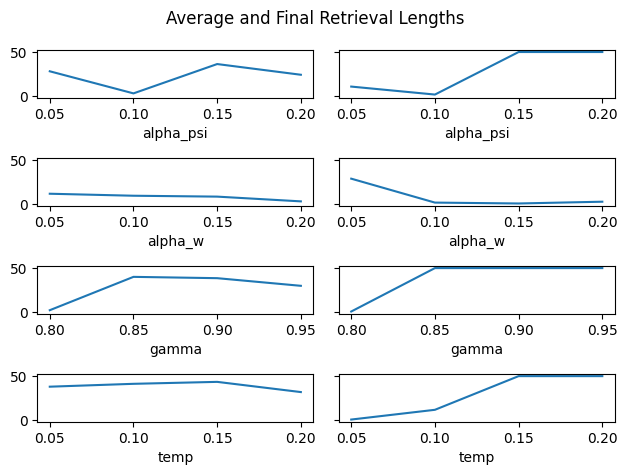

In [97]:
def exp_1(opt, params, n, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
            if opt == "alpha_psi":
                agent = model.FeatureAgent(environment, alpha_psi=p)
            elif opt == "alpha_w":
                agent = model.FeatureAgent(environment, alpha_w=p)
            elif opt == "gamma":
                agent = model.FeatureAgent(environment, gamma=p)
            elif opt == "temp":
                agent = model.FeatureAgent(environment, temp=p)
            test = model.Simulator(agent, environment)
            test.run(n, 50, time=1, delta=20)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval


default_rewards[0] = -100
fig, axs = plt.subplots(4, 2, sharey=True)
alphas = [n / 20 for n in range(1, 5)]
gammas = [n / 20 for n in range(16, 20)]
temps = [n / 20 for n in range(1, 5)]
ax_count = 0
for opt, params in {"alpha_psi": alphas, "alpha_w": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=1)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

temp 0.01 is finished
temp 0.02 is finished
temp 0.03 is finished
temp 0.04 is finished
temp 0.05 is finished
temp 0.06 is finished
temp 0.07 is finished
temp 0.08 is finished
temp 0.09 is finished
temp 0.1 is finished
temp 0.11 is finished
temp 0.12 is finished
temp 0.13 is finished
temp 0.14 is finished
temp 0.15 is finished
temp 0.16 is finished
temp 0.17 is finished
temp 0.18 is finished
temp 0.19 is finished
temp 0.2 is finished


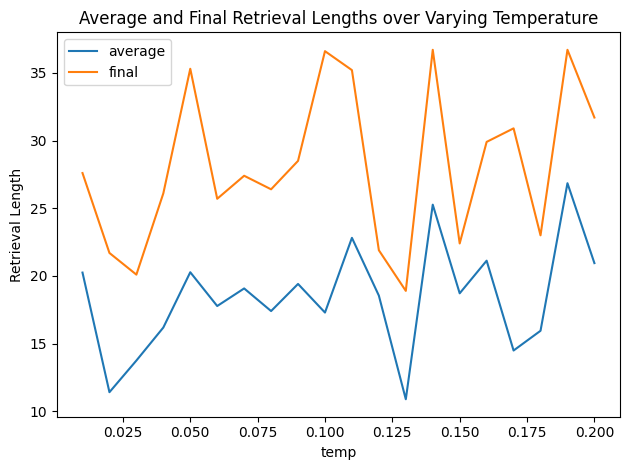

In [288]:
temps = [n / 100 for n in range(1, 21)]
default_rewards[0] = -20
avg_retrieval = []
final_retrieval = []
for temp in temps:
    rep_avg = []
    rep_final = []
    for _ in range(10):
        environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
        agent = model.FeatureAgent(environment, temp=temp)
        test = model.Simulator(agent, environment)
        test.run(100, 50, time=0.1, delta=20)
        retrieval_length = [len(trial) for trial in test.record]
        rep_avg.append(np.mean(retrieval_length))
        rep_final.append(retrieval_length[-1])
    avg_retrieval.append(np.mean(rep_avg))
    final_retrieval.append(np.mean(rep_final))
    print(f"temp {temp} is finished")
sns.lineplot(x=temps, y=avg_retrieval, label="average")
sns.lineplot(x=temps, y=final_retrieval, label="final")
plt.xlabel("temp")
plt.ylabel("Retrieval Length")
plt.title("Average and Final Retrieval Lengths over Varying Temperature")
plt.legend()
plt.tight_layout()
plt.savefig("temp_exp.png")
plt.show()

rep 0 finished
rep 1 finished
rep 2 finished
rep 3 finished
rep 4 finished
rep 5 finished
rep 6 finished
rep 7 finished
rep 8 finished
rep 9 finished
rep 10 finished
rep 11 finished
rep 12 finished
rep 13 finished
rep 14 finished
rep 15 finished
rep 16 finished
rep 17 finished
rep 18 finished
rep 19 finished
rep 0 finished
rep 1 finished
rep 2 finished
rep 3 finished
rep 4 finished
rep 5 finished
rep 6 finished
rep 7 finished
rep 8 finished
rep 9 finished
rep 10 finished
rep 11 finished
rep 12 finished
rep 13 finished
rep 14 finished
rep 15 finished
rep 16 finished
rep 17 finished
rep 18 finished
rep 19 finished


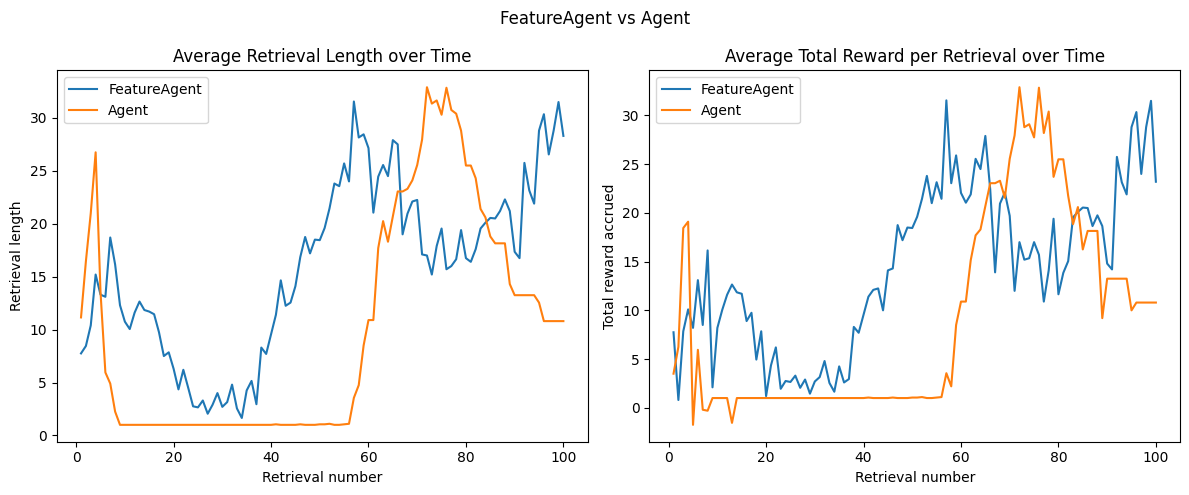

In [4]:
def collect_trajectories(agent_factory, n=100, max_steps=50, reps=20):
    length_trajectories = []
    reward_trajectories = []
    for _ in range(reps):
        environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
        agent = agent_factory(environment)
        sim = model.Simulator(agent, environment)
        sim.run(n, max_steps, time=0.1, delta=20)
        length_trajectories.append([len(trial) for trial in sim.record])
        reward_trajectories.append(sim.reward_totals)
        print(f"rep {_} finished")
    return np.array(length_trajectories), np.array(reward_trajectories)

default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -50

# v_i=0 equalizes Agent's starting value with FeatureAgent's (psi=w=0 -> value=0),
# so both start from the same neutral sigmoid(0/temp)=0.5 recall probability.
feature_lengths, feature_rewards = collect_trajectories(lambda env: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05))
agent_lengths, agent_rewards = collect_trajectories(lambda env: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05))

retrieval_num = np.arange(1, feature_lengths.shape[1] + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(retrieval_num, feature_lengths.mean(axis=0), label="FeatureAgent")
axs[0].plot(retrieval_num, agent_lengths.mean(axis=0), label="Agent")
axs[0].set_xlabel("Retrieval number")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length over Time")
axs[0].legend()

axs[1].plot(retrieval_num, feature_rewards.mean(axis=0), label="FeatureAgent")
axs[1].plot(retrieval_num, agent_rewards.mean(axis=0), label="Agent")
axs[1].set_xlabel("Retrieval number")
axs[1].set_ylabel("Total reward accrued")
axs[1].set_title("Average Total Reward per Retrieval over Time")
axs[1].legend()

fig.suptitle("FeatureAgent vs Agent")
plt.tight_layout()
plt.show()